**Sofiia Chorna**

**Project 2**
You will work with the Fashion MNIST dataset, aiming to implement a Conditional Generative Adversarial Network (Conditional GAN) to generate images from this dataset. Start by splitting the dataset into training and test sets. While maintaining simplicity, focus on devising an innovative approach to analyze the test dataset using the Conditional GAN model. Employ data science techniques to explore and gain valuable insights from the generated data.


# Implementatioin

## Dataset preparation

### Loading data

In [1]:
from torchvision.datasets import FashionMNIST
from torchvision.transforms import ToTensor


train_ds = FashionMNIST("./data", train=True, transform=ToTensor(), download=True)
test_ds = FashionMNIST("./data", train=False, transform=ToTensor(), download=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.5MB/s]


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 199kB/s]


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 3.74MB/s]


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 7.85MB/s]

Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



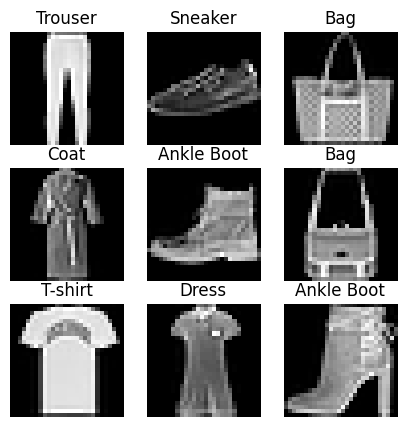

In [3]:
import torch
import matplotlib.pyplot as plt


labels_map={
    0: 'T-shirt',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle Boot',
}

figure = plt.figure(figsize = (5,5))
cols, rows = 3, 3

for i in range (1, cols*rows + 1):
  sample_idx = torch.randint(len(train_ds), size = (1,)).item()
  image, label = train_ds[sample_idx]
  figure.add_subplot(rows, cols, i)

  plt.title(labels_map[label])
  plt.axis('off')
  plt.imshow(image.squeeze(), cmap='gray')

plt.show()

### Dataloaders

In [12]:
from torch.utils.data import DataLoader


train_dataloader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_ds, batch_size=64, shuffle=True)

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64, 1, 28, 28])

Label: 7


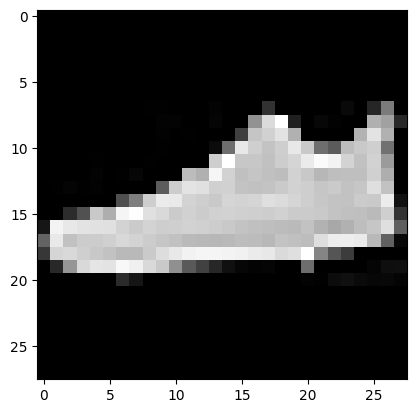

In [13]:
train_features, train_labels = next(iter(train_dataloader))

print("Feature batch shape:", train_features.size())
print("Labels batch shape:", train_features.size())

img = train_features[0].squeeze()
label = train_labels[0]

print(f"\nLabel: {label}")
plt.imshow(img, cmap="gray")
plt.show()

## CGAN implementation

For the implementation, it was followed the desciption of the architecture from the CGAN paper (Mirza, Osindero, 2014). In the following plot I illustrate the schema of the models &#128523;

In [14]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

### Generator

In [27]:
import torch.nn as nn
import torch.nn.functional as F


class Generator(nn.Module):
  def __init__(self, z_dim=100, n_classes=10, img_dim=28):
    super().__init__()

    # params
    self.z_dim = z_dim  # noise vector size
    self.n_classes = n_classes
    self.img_dim = img_dim # output image size

    # fully connected layers for noise and labels
    self.fc_noise = nn.Sequential(
        nn.Linear(z_dim, 200),
        nn.ReLU(),
        nn.Dropout(0)
    )
    self.fc_label = nn.Sequential(
        nn.Linear(n_classes, 1000),
        nn.ReLU(),
        nn.Dropout(0)
    )

    # combined layers
    self.fc_combined = nn.Sequential(
        nn.Linear(200 + 1000, 1200),
        nn.ReLU(),
        nn.Dropout(0)
    )

    # output layer to map to image dims
    self.fc_output = nn.Sequential(
        nn.Linear(1200, img_dim * img_dim),
        nn.Sigmoid()  # output in [0, 1]
    )

  def forward(self, noise, labels):
    # one-hot encode labels
    labels_one_hot = F.one_hot(labels, num_classes=self.n_classes).float()

    # process noise and embedded labels separately
    noise_vector = self.fc_noise(noise)
    label_vector = self.fc_label(labels_one_hot)

    # pass through combined layer
    combined_vector = self.fc_combined(torch.cat([noise_vector, label_vector], dim=1))

    # generate image
    img = self.fc_output(combined_vector)
    img = img.view(-1, 1, self.img_dim, self.img_dim)  # reshape to (batch_size, 1, 28, 28)

    return img


### Discriminator

First let's implement Maxout activation mentioned in the CGAN paper [1], they found that maxout units are typically well suited to the task. I implement it by following Maxout paper [2] &#129299;

In [16]:
class Maxout(nn.Module):
  def __init__(self, d_in, num_units, num_piece):
    super().__init__()

    # params
    self.d_in = d_in
    self.num_units = num_units
    self.num_piece = num_piece

    # layer
    self.linear = nn.Linear(d_in, num_units * num_piece)

  def forward(self, x):
    x = self.linear(x)

    # reshape to (batch_size, units, pieces)
    x = x.view(-1, self.num_units, self.num_piece)

    # take the max across pieces => suite au nom d'activation :)
    x = torch.max(x, dim=2).values

    return x

Now, the discriminator

In [28]:
class Discriminator(nn.Module):
  def __init__(self, n_classes=10, img_dim=28):
    super().__init__()

    # params
    self.n_classes = n_classes
    self.img_dim = img_dim

    # layers for images and labels
    self.maxout_img = Maxout(d_in=img_dim * img_dim, num_piece=5, num_units=240)
    self.maxout_label = Maxout(d_in=n_classes, num_piece=5, num_units=50)

    # combined layer
    self.maxout_combined = Maxout(d_in=240 + 50, num_piece=4, num_units=240)

    # output layer
    self.linear_output = nn.Linear(240, 1)
    self.dropout = nn.Dropout(0)

    # output in binary value
    self.sigmoid = nn.Sigmoid()

  def forward(self, img, labels):
    # pass image
    x_img = img.view(-1, self.img_dim * self.img_dim)  # flatten
    x_img = self.maxout_img(x_img)
    x_img = self.dropout(x_img)

    # pass labels
    labels_one_hot = F.one_hot(labels, num_classes=self.n_classes).float()
    x_label = self.maxout_label(labels_one_hot)
    x_label = self.dropout(x_label)

    # combined layer
    combined = torch.cat((x_img, x_label), dim=1)
    combined = self.maxout_combined(combined)
    combined = self.dropout(combined)

    # result: fake or not
    output = self.sigmoid(self.linear_output(combined))

    return output


## Training

### Training setup

In [18]:
z_dim = 100
n_classes = 10
img_dim = 28

In [19]:
generator = Generator(z_dim, n_classes, img_dim).to(device)
discriminator = Discriminator(n_classes, img_dim).to(device)

Binary cross-entropy as we need to map the result to true or false (fake ok not).

In [20]:
generator_loss = nn.BCELoss()

In [21]:
def discriminator_loss(real_output, fake_output, real_labels, fake_labels):
  criteria = nn.BCELoss()
  real_loss = criteria(real_output, real_labels)
  fake_loss = criteria(fake_output, fake_labels)
  return (real_loss + fake_loss) / 2

For optimizer, I use stochastic gradient descent with momentum

In [22]:
lr = 0.1
dropout_prob = 0.5

In [23]:
from torch.optim import SGD


momentum = 0.5

generator_optimizer = SGD(generator.parameters(), lr=lr, momentum=momentum)
discriminator_optimizer = SGD(discriminator.parameters(), lr=lr, momentum=momentum)

Exponential decay is taked as a learning rate scheduler

In [24]:
from torch.optim.lr_scheduler import ExponentialLR


decay_factor = 1.00004

generator_scheduler = ExponentialLR(generator_optimizer, gamma=decay_factor)
discriminator_scheduler = ExponentialLR(discriminator_optimizer, gamma=decay_factor)

### Training loop

Train discriminator

In [45]:
import os
from tqdm import tqdm
from matplotlib import pyplot as plt


g_losses, d_losses = [], []

def train(generator, discriminator, gen_optimizer, disc_optimizer, dataloader, num_epochs, save_interval=100, log_interval=100, checkpoint_path=""):

  # setup folders
  checkpoint_dir = "./checkpoints"
  os.makedirs(checkpoint_dir, exist_ok=True)

  save_dir = "./generated_samples"
  os.makedirs(save_dir, exist_ok=True)

  start_epoch = 0

  if checkpoint_path and os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    generator.load_state_dict(checkpoint['generator_state_dict'])
    discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
    gen_optimizer.load_state_dict(checkpoint['generator_optimizer_state_dict'])
    disc_optimizer.load_state_dict(checkpoint['discriminator_optimizer_state_dict'])
    start_epoch = checkpoint['epoch']  # Set starting epoch from checkpoint

    print(f"Resuming from epoch {start_epoch}...")

  # Training loop
  for epoch in range(start_epoch, num_epochs):
    g_loss_epoch, d_loss_epoch = 0.0, 0.0

    for i, (images, labels) in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")):
      batch_size = images.size(0)
      real_images = images.view(batch_size, -1).to(device)  # flatten images
      labels = labels.to(device)

      # labels for real (1s) and fake (0s) images
      real_labels = torch.ones(batch_size, 1).to(device)
      fake_labels = torch.zeros(batch_size, 1).to(device)


      # ---- train discriminator ----
      discriminator_optimizer.zero_grad()

      # real images
      real_output = discriminator(real_images, labels)

      # fake images
      noise = torch.randn(batch_size, z_dim).to(device)
      fake_images = generator(noise, labels)
      fake_output = discriminator(fake_images.detach(), labels)

      # get loss
      disc_loss = discriminator_loss(real_output, fake_output, real_labels, fake_labels)
      disc_loss.backward()
      discriminator_optimizer.step()


      # ---- train generator ----
      generator_optimizer.zero_grad()

      # get fake images
      fake_output = discriminator(fake_images, labels)

      # get loss
      gen_loss = generator_loss(fake_output, real_labels)
      gen_loss.backward()
      generator_optimizer.step()


      # sum losses
      g_loss_epoch += gen_loss.item()
      d_loss_epoch += disc_loss.item()

    # update learning rate
    generator_scheduler.step()
    discriminator_scheduler.step()

    # average losses for this epoch
    g_losses.append(g_loss_epoch / len(dataloader))
    d_losses.append(d_loss_epoch / len(dataloader))

    print("Gen loss:", g_losses[-1], "Disc loss:", d_losses[-1])

    # save checkpoint periodically
    if (epoch + 1) % 10 == 0:
      checkpoint = {
          "epoch": epoch,
          "generator_state_dict": generator.state_dict(),
          "discriminator_state_dict": discriminator.state_dict(),
          "generator_optimizer_state_dict": generator_optimizer.state_dict(),
          "discriminator_optimizer_state_dict": discriminator_optimizer.state_dict(),
          'gen_loss': g_loss_epoch,
          'disc_loss': d_loss_epoch,
      }
      torch.save(checkpoint, os.path.join(checkpoint_dir, f"cgan_checkpoint_epoch_{epoch+1}.pth"))
      print("Checkpoint saved for epoch", epoch+1)

    # save generated samples and labels periodically
    if (epoch + 1) % 10 == 0:
        generator.eval()
        with torch.no_grad():
            noise = torch.randn(16, z_dim).to(device)
            # Generate labels within the valid range (0-9)
            labels = torch.randint(0, n_classes, (16,)).to(device)
            fake_images = generator(noise, labels).view(-1, 1, 28, 28).cpu()

            # Save the labels in a text file
            labels_filename = os.path.join(save_dir, f"labels_epoch_{epoch+1}.txt")
            with open(labels_filename, 'w') as f:
                f.write("Labels for generated samples:\n")
                f.write(str(labels.tolist()))  # Write the list of labels

            # Arrange images in a grid
            grid = torch.cat([fake_images[i] for i in range(16)], dim=2)
            plt.imshow(grid.squeeze(), cmap="gray")
            plt.title(f"Generated Samples at Epoch {epoch+1}")
            plt.axis("off")
            plt.savefig(os.path.join(save_dir, f"generated_samples_epoch_{epoch+1}.png"))
            plt.close()
        generator.train()


  checkpoint = {
    "epoch": epoch,
    "generator_state_dict": generator.state_dict(),
    "discriminator_state_dict": discriminator.state_dict(),
    "generator_optimizer_state_dict": generator_optimizer.state_dict(),
    "discriminator_optimizer_state_dict": discriminator_optimizer.state_dict(),
    'gen_loss': g_loss_epoch,
    'disc_loss': d_loss_epoch,
  }
  torch.save(checkpoint, os.path.join(checkpoint_dir, f"cgan_checkpoint_epoch_{epoch+1}.pth"))
  print("Checkpoint saved for epoch", epoch+1)


#### Run training

In [ ]:
train(generator, discriminator, generator_optimizer, discriminator_optimizer,train_dataloader, num_epochs=200)

Epoch 1/200: 100%|██████████| 938/938 [00:13<00:00, 67.27it/s]


Gen loss: 0.8629414746756239 Disc loss: 0.6621945420943344


Epoch 2/200: 100%|██████████| 938/938 [00:14<00:00, 66.81it/s]


Gen loss: 0.8633786638789593 Disc loss: 0.6610054043310283


Epoch 3/200: 100%|██████████| 938/938 [00:15<00:00, 60.58it/s]


...

Epoch 89/200: 100%|██████████| 938/938 [00:13<00:00, 67.18it/s]


Gen loss: 0.8921469766448047 Disc loss: 0.6559184620629496


Epoch 90/200: 100%|██████████| 938/938 [00:14<00:00, 64.72it/s]


Gen loss: 0.8970865973277387 Disc loss: 0.6558633333584393
Checkpoint saved for epoch 90


Epoch 91/200:  23%|██▎       | 215/938 [00:03<00:10, 71.19it/s]

In [41]:
import time


def plot_losses(gen_losses, disc_losses, save_dir):
    plt.figure(figsize=(10, 5))
    plt.plot(gen_losses, label="Generator Loss")
    plt.plot(disc_losses, label="Discriminator Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Generator and Discriminator Loss Over Epochs")
    timestamp = time.strftime("%Y%m%d-%H%M%S")
    plt.savefig(os.path.join(save_dir, f"loss_plot_{timestamp}.png"))
    plt.close()


plot_losses(g_losses, d_losses, "checkpoints")

In [ ]:
import os
import torch
import matplotlib.pyplot as plt
import time

def plot_losses_from_checkpoints(checkpoint_dir, save_dir):
    gen_losses = []
    disc_losses = []

    # Iterate over all checkpoint files in the checkpoint directory
    for filename in os.listdir(checkpoint_dir):
        if filename.endswith(".pth"):  # Assuming the checkpoint files have the .pth extension
            checkpoint_path = os.path.join(checkpoint_dir, filename)
            checkpoint = torch.load(checkpoint_path)

            # Extract and accumulate the losses
            gen_losses.append(checkpoint['gen_loss'])
            disc_losses.append(checkpoint['disc_loss'])

    # Plot the losses
    plt.figure(figsize=(10, 5))
    plt.plot(gen_losses, label="Generator Loss")
    plt.plot(disc_losses, label="Discriminator Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Generator and Discriminator Loss Over Epochs")

    # Save the plot with a timestamp
    timestamp = time.strftime("%Y%m%d-%H%M%S")
    plt.savefig(os.path.join(save_dir, f"loss_plot_{timestamp}.png"))
    plt.close()

# Call the function to plot losses from all checkpoints
plot_losses_from_checkpoints('./checkpoints', './generated_samples')


# Analyse

# Reference papers



[1]  List item

[2] Goodfellow, I. J., Warde-Farley, D., Mirza, M., Courville, A., and Bengio, Y. (2013). Maxout networks. In ICML 2013. https://arxiv.org/pdf/1302.4389

